In [1]:
import os
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import transforms
from tqdm.notebook import tqdm

from captum.attr import visualization as viz
from matplotlib.colors import LinearSegmentedColormap
from src.models.train import AsparagusScoring

default_cmap = LinearSegmentedColormap.from_list('custom blue', 
                                                 [(0, '#ffffff'),
                                                  (0.25, '#000000'),
                                                  (1, '#000000')])

In [2]:
checkpoint1 = '/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/maskout_6/cp_epoch=39_val_loss=0.005_val_R2=0.902.ckpt'
checkpoint2 = '/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/maskout_8/cp_epoch=17_val_loss=0.005_val_R2=0.894.ckpt'
system = AsparagusScoring.load_from_checkpoint(checkpoint1)
hparams = system.hparams
device = torch.device('cuda:0')
system.freeze()

In [3]:
system

AsparagusScoring(
  (model): AsparagusHeadScorer(
    (encoder): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (r

In [4]:
model = system.model

for name, param in model.named_parameters():
    print(name)

encoder.conv1.weight
encoder.bn1.weight
encoder.bn1.bias
encoder.layer1.0.conv1.weight
encoder.layer1.0.bn1.weight
encoder.layer1.0.bn1.bias
encoder.layer1.0.conv2.weight
encoder.layer1.0.bn2.weight
encoder.layer1.0.bn2.bias
encoder.layer1.0.conv3.weight
encoder.layer1.0.bn3.weight
encoder.layer1.0.bn3.bias
encoder.layer1.0.downsample.0.weight
encoder.layer1.0.downsample.1.weight
encoder.layer1.0.downsample.1.bias
encoder.layer1.1.conv1.weight
encoder.layer1.1.bn1.weight
encoder.layer1.1.bn1.bias
encoder.layer1.1.conv2.weight
encoder.layer1.1.bn2.weight
encoder.layer1.1.bn2.bias
encoder.layer1.1.conv3.weight
encoder.layer1.1.bn3.weight
encoder.layer1.1.bn3.bias
encoder.layer1.2.conv1.weight
encoder.layer1.2.bn1.weight
encoder.layer1.2.bn1.bias
encoder.layer1.2.conv2.weight
encoder.layer1.2.bn2.weight
encoder.layer1.2.bn2.bias
encoder.layer1.2.conv3.weight
encoder.layer1.2.bn3.weight
encoder.layer1.2.bn3.bias
encoder.layer2.0.conv1.weight
encoder.layer2.0.bn1.weight
encoder.layer2.0.bn1

In [5]:
hparams

Namespace(alpha=0.2, augmentation='none', batch_size=16, checkpoints_path='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/', es_patience=21, experiment_name='asparagus_test_run', gpus=[0, 1], images_dir='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/images/', labels='data/combined/LABELS.txt', labels_file='data/combined/annotations.csv', load_checkpoint_file=None, lr=0.0001, lr_end=1e-06, maskout=True, max_epochs=500, max_grad_norm=10.0, mixup=False, mode='pad', model_hyperparams={'encoder_class': 'torchvision.models.resnet50', 'encoder_hyperparams': {'pretrained': 'imagenet'}, 'num_input': 1000, 'num_output': 1}, n_checkpoints=1, note=' resnet18 with filter images', num_workers=12, optimizer='adam', run_name='maskout_6', sampler='default', scheduler='Cosine', size=512, tracking_uri='http://qge-dev-dock-01.dev.rd.rijkzwaan.net:5000', train_names='data/combined/TRAIN.txt', val_names='data/combined/VAL.txt', weight_decay=0)

In [6]:
from src.data.datasets import Scoring, ScoringTest

#dataset = ScoringTest(size=hparams.size,
#                      mode=hparams.mode,
#                      images_dir='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/images/',
#                      maskout=hparams.maskout)
names = np.loadtxt('/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/splits/VAL.txt', dtype=str)
dataset = Scoring(names=names,
                  labels_file='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/annotations.csv',
                  size=hparams.size,
                  mode=hparams.mode,
                  images_dir='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/images/',
                  maskout=hparams.maskout)

In [7]:
img, score = dataset[40]
print(img.shape)

torch.Size([3, 512, 512])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


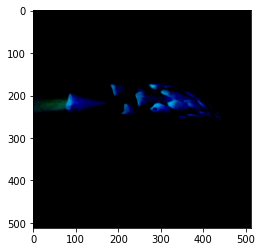

In [8]:
plt.imshow(img.permute(1,2,0) )

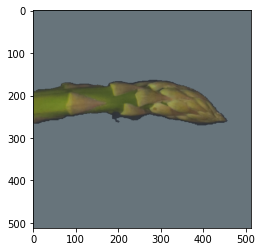

In [9]:
mean=(0.485, 0.456, 0.406)
std=(0.229, 0.224, 0.225)
img1 = np.moveaxis(img.numpy(), 0, -1)
img1 = 255*(img1 * std + mean)
img1 = img1[:, :, ::-1].astype(int)
plt.imshow(img1)

In [10]:
normalize = transforms.Normalize(
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)
                                            )
norm_img = normalize(img)

In [11]:
input_img = norm_img.unsqueeze(0)
print(input_img.shape)

torch.Size([1, 3, 512, 512])


In [12]:
pred = system(input_img)
# Prediction output
pred 

tensor([[1.0000]])

# Captum Intergrated Gradients (Gradient)

We will let the baseline be the zero vector (a black image) <br>=> input_img * 0 
<br><br>
Since the model is a regression classification model, no target class is provided.

In [14]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(model)

In [15]:
attr_ig = ig.attribute(input_img,
                       baselines = input_img * 0,
                       #target = target_class_index,
                       n_steps=50)

source code of captum.attr.visualization <br>
https://github.com/pytorch/captum/blob/master/captum/attr/_utils/visualization.py

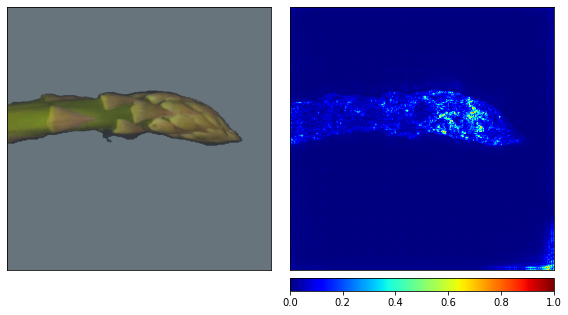

In [16]:
# visualizing the image and corresponding attribu
# tions by overlaying the latter on the image.

_ = viz.visualize_image_attr_multiple(np.transpose(attr_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                             img1, 
                             ["original_image", "heat_map"],
                             ["all", "absolute_value"],
                             cmap='jet',
                             show_colorbar=True)

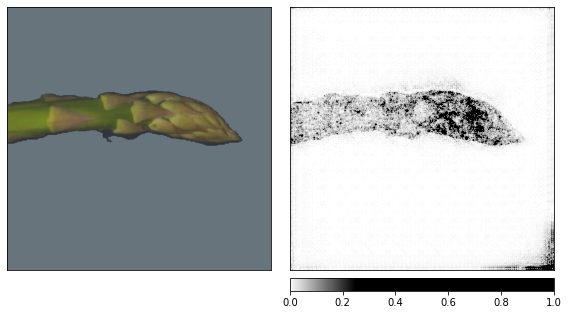

In [17]:
fig, axis = viz.visualize_image_attr_multiple(np.transpose(attr_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                             img1,
                             ["original_image", "heat_map"],
                             ["all", "absolute_value"],
                             cmap=default_cmap,
                             show_colorbar=True)
                            

VAL.txt includes the names of image files.

In [18]:
file = open('/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/splits/VAL.txt', 'r') 
lines = file.readlines()
file_name = []
for line in lines: 
    line = line.rstrip()
    file_name.append(line)
file_name = sorted(file_name)

In [19]:
file_name[40]

'set2_39_024_ill_H2.png'

In [21]:
savedir = '/home/SOKI/ImageFiles/asparagus_head_scoring/Captum/'
fig.savefig(savedir+ 'set2_39_024_ill_H2.png')

### Run iteratively all images to create Intergrated Gradients results

  0%|          | 0/310 [00:00<?, ?it/s]

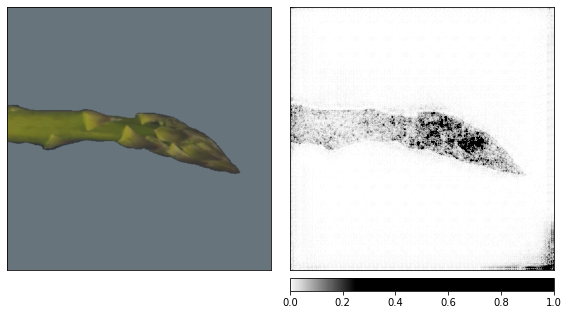

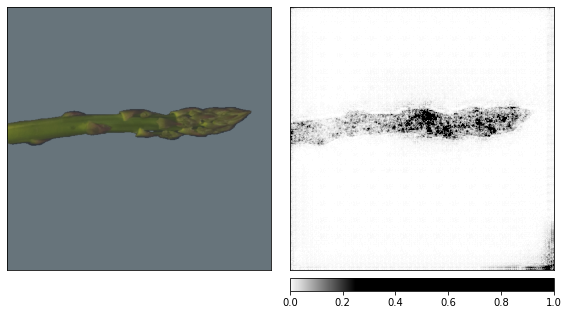

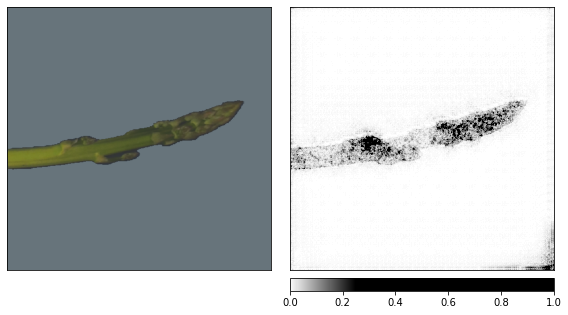

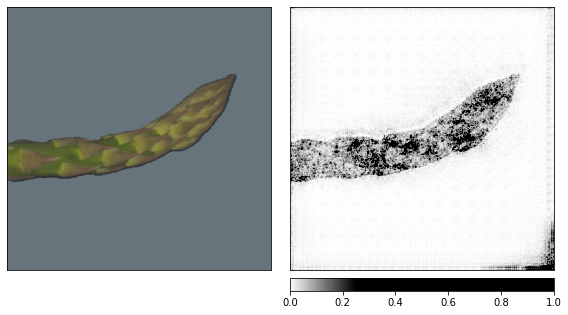

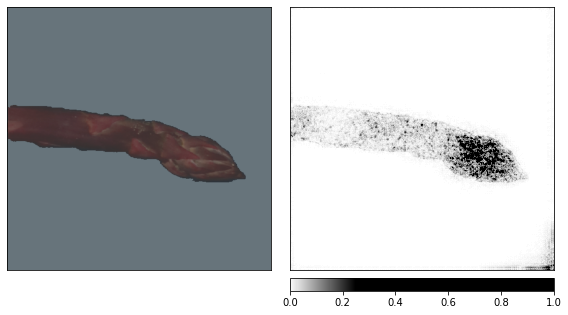

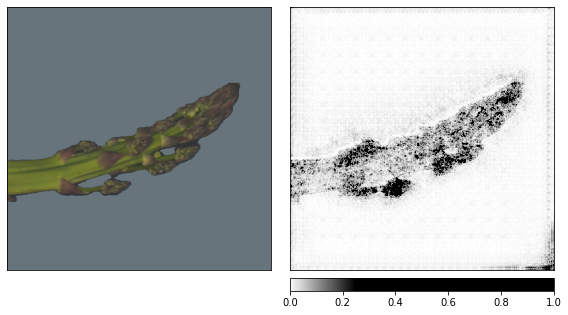

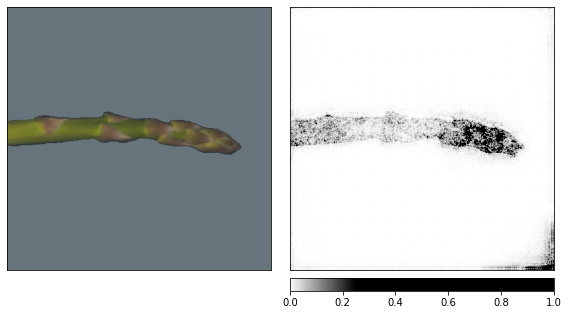

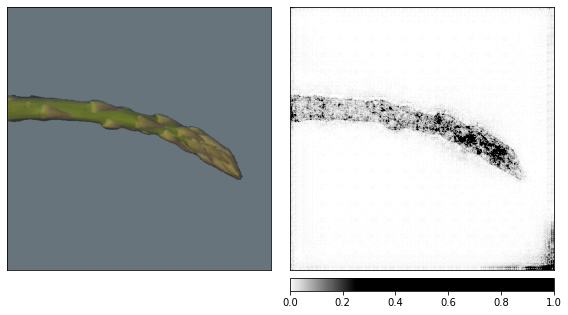

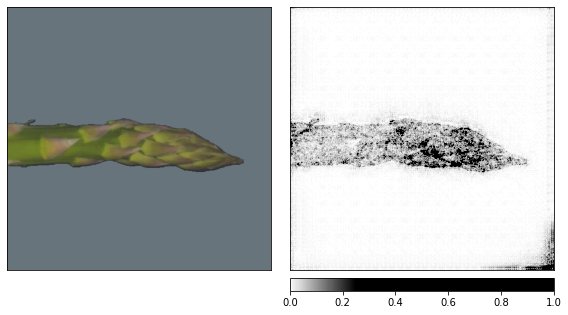

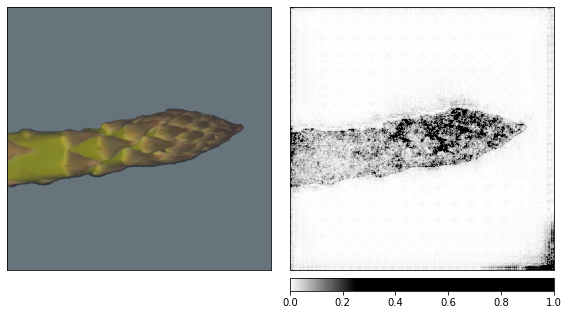

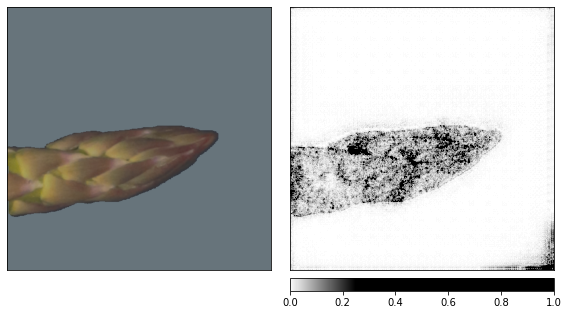

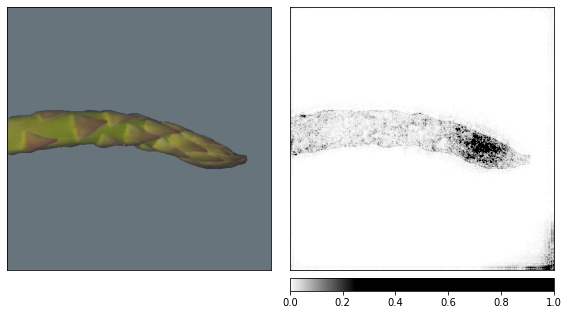

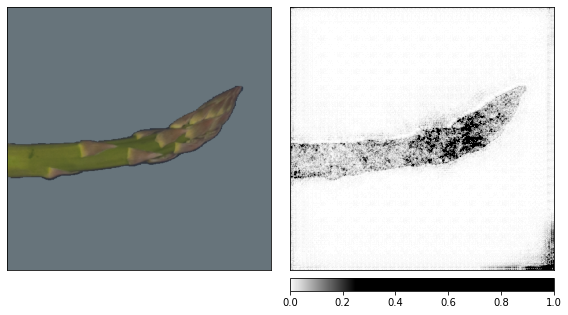

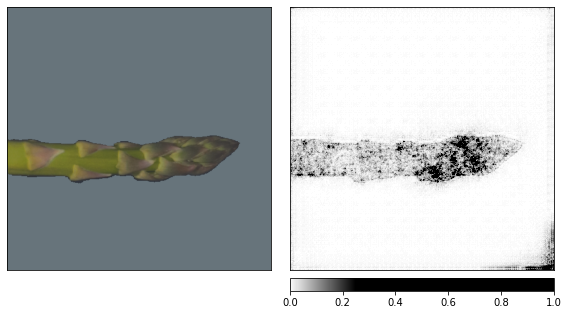

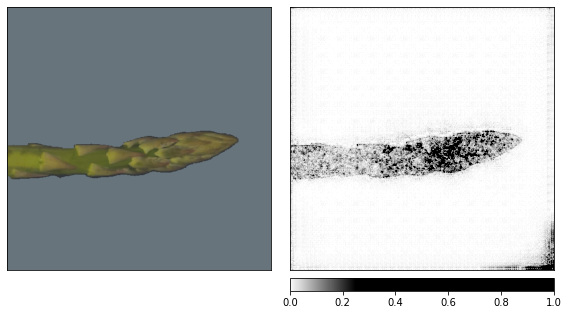

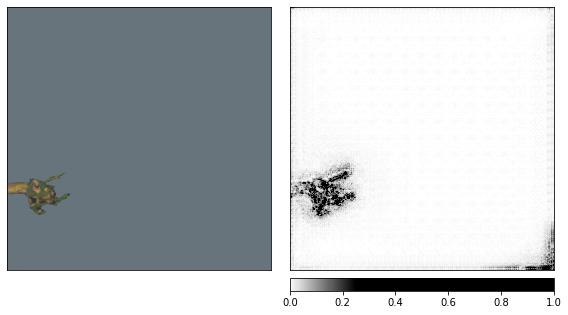

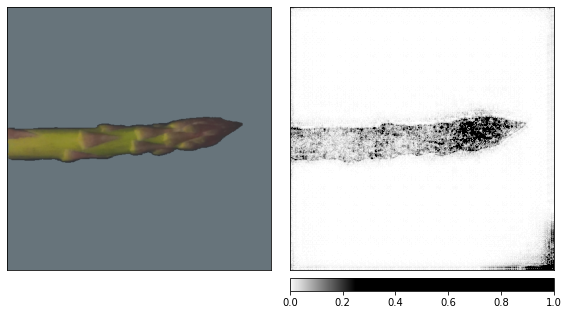

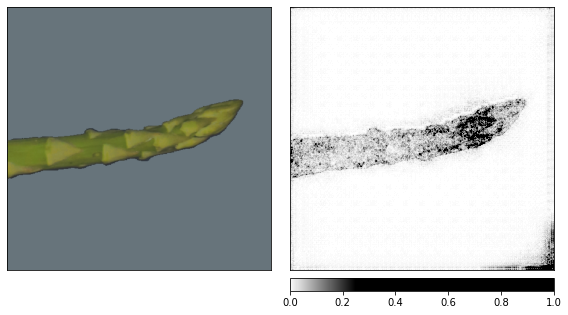

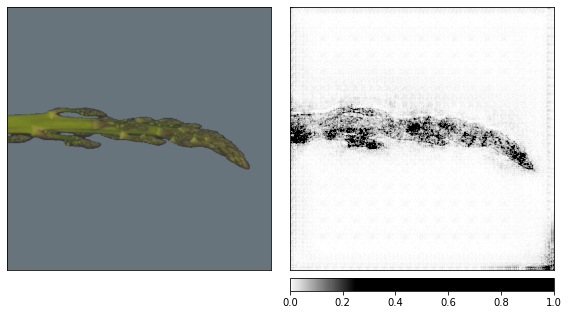

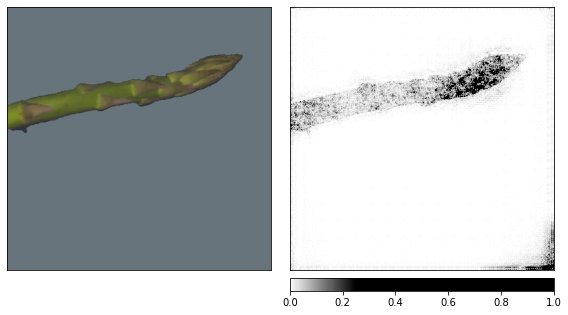

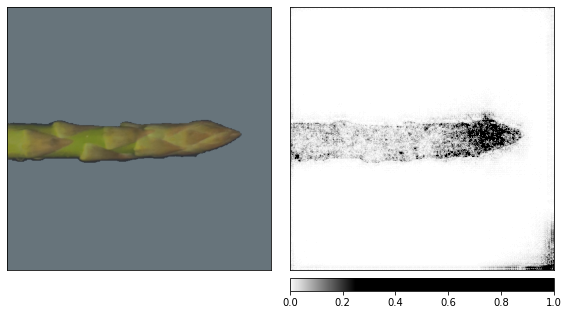

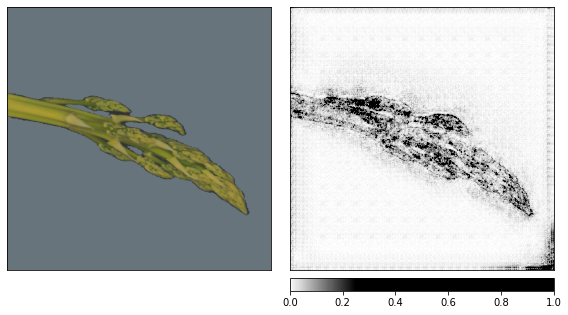

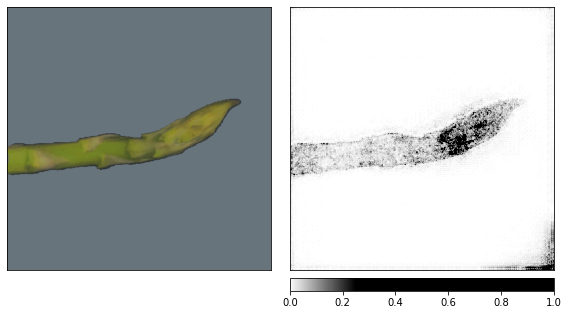

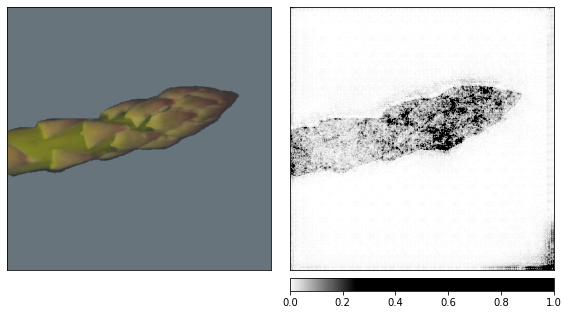

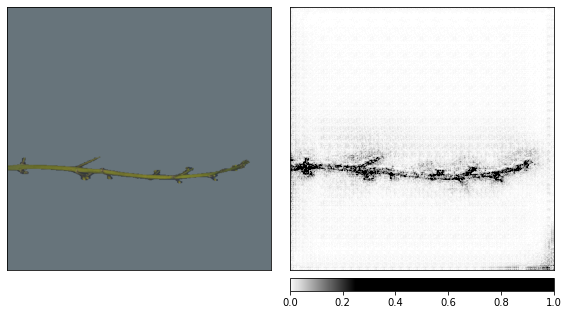

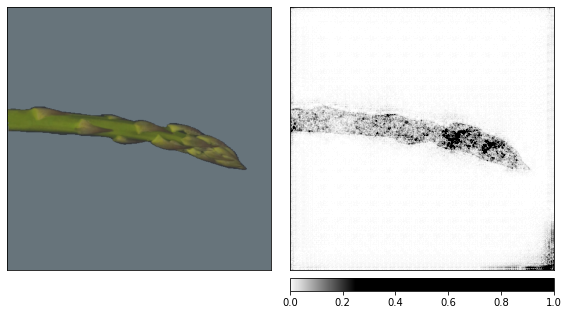

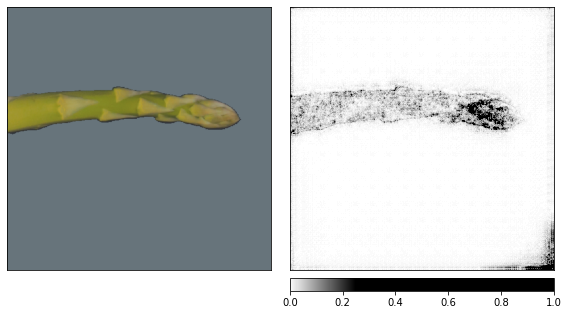

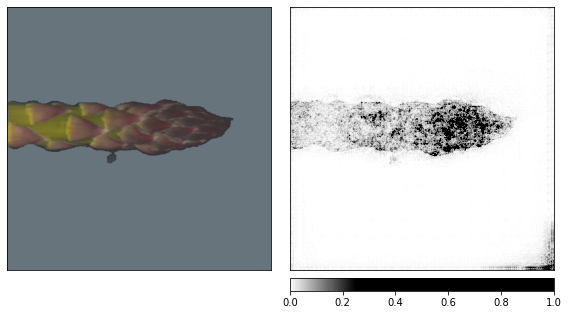

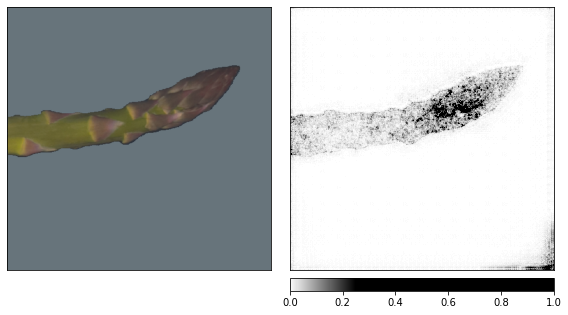

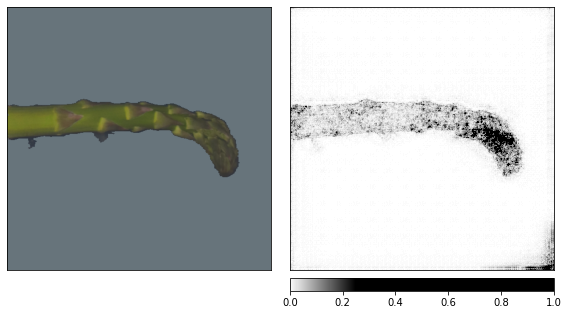

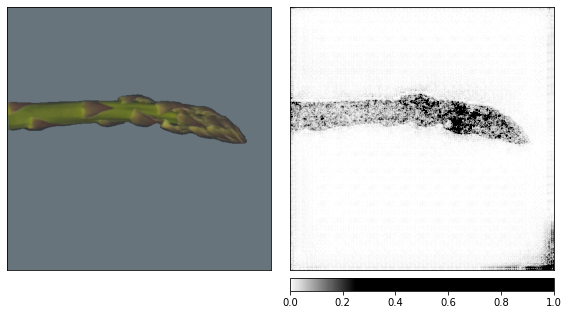

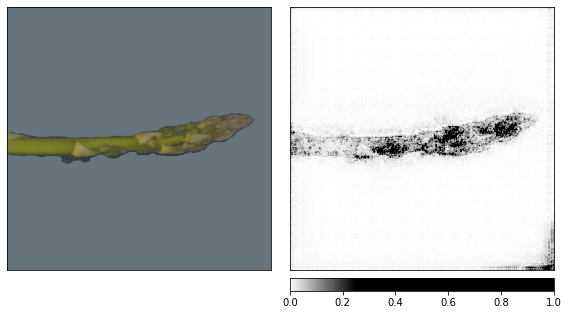

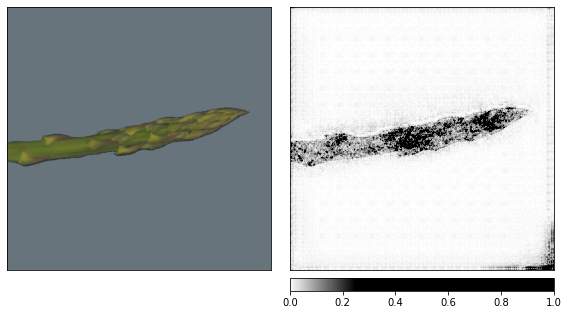

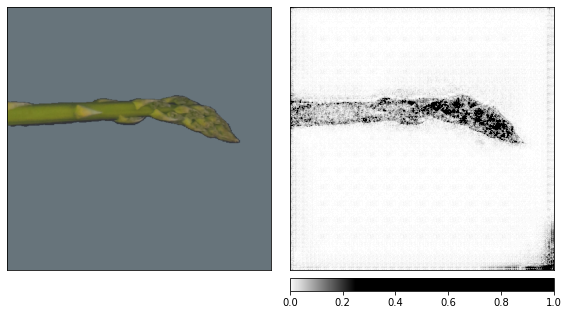

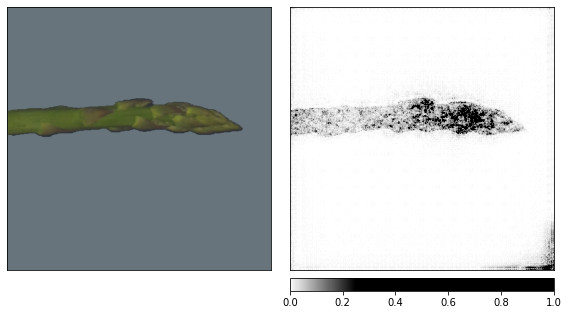

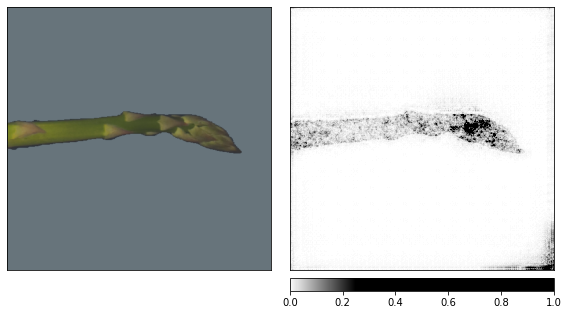

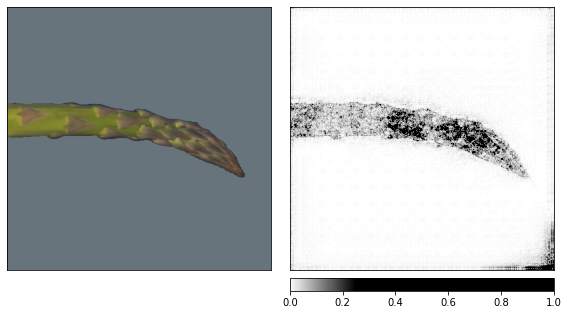

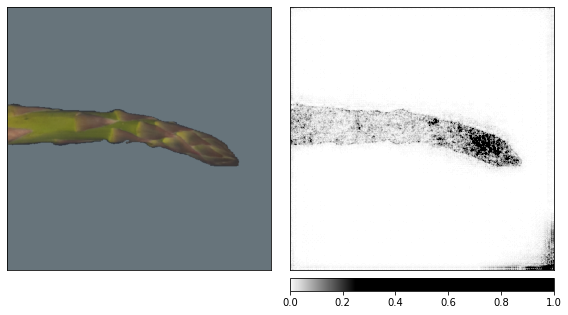

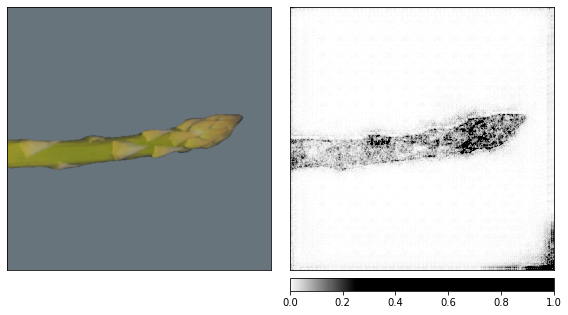

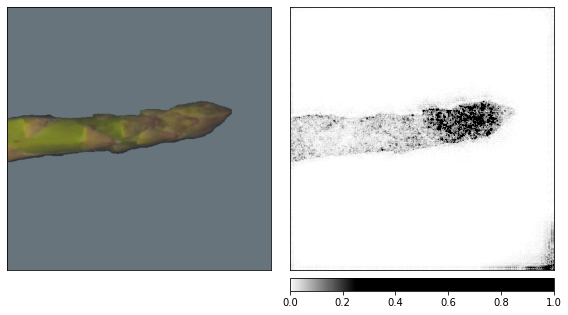

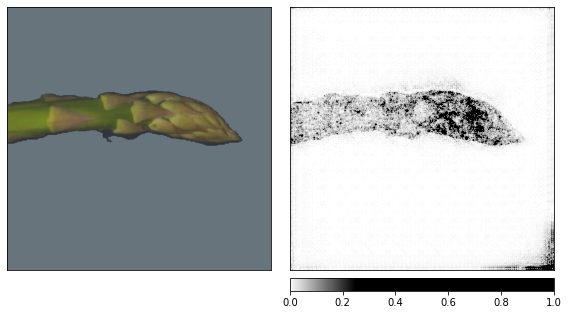

KeyboardInterrupt: 

In [20]:
idx = 0

for img, score in tqdm(dataset): 
    # original image
    mean=(0.485, 0.456, 0.406)
    std=(0.229, 0.224, 0.225)
    img1 = np.moveaxis(img.numpy(), 0, -1)
    img1 = 255*(img1 * std + mean)
    img1 = img1[:, :, ::-1].astype(int)
    
    # preprocessed image
    norm_img = normalize(img)
    input_img = norm_img.unsqueeze(0)
    
    # attribution image
    attr_ig = ig.attribute(input_img,
                           baselines=input_img*0,
                           n_steps=50)
    
    # visualization of 1)original image and 2)attribution image
    fig,axis = viz.visualize_image_attr_multiple(np.transpose(attr_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                             img1,
                             ["original_image", "heat_map"],
                             ["all", "absolute_value"],
                             cmap=default_cmap,
                             show_colorbar=True)
    
    savedir = '/home/SOKI/ImageFiles/asparagus_head_scoring/Captum/IG/'
    fig.savefig(savedir+ file_name[idx])
    idx += 1

# Captum Gradient SHAP (Gradient)

In [23]:
from captum.attr import GradientShap

gradient_shap = GradientShap(model)

# Defining baseline distribution of images
rand_img_dist = torch.cat([input_img * 0, input_img * 1])

In [14]:
attr_gradSHAP = gradient_shap.attribute(input_img,
                        baselines=rand_img_dist,
                        n_samples=50,
                        stdevs=0.03)

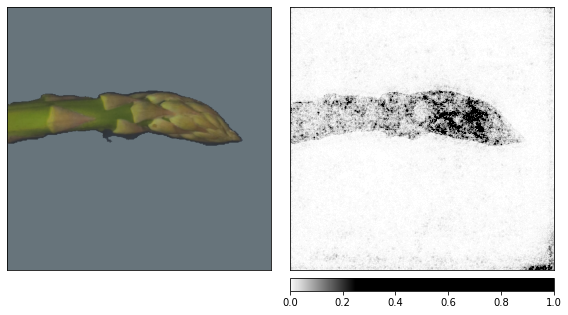

In [15]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_gradSHAP.squeeze().cpu().detach().numpy(), (1,2,0)),
                             img1,
                             ["original_image", "heat_map"],
                             ["all", "absolute_value"],
                             cmap=default_cmap,
                             show_colorbar=True)

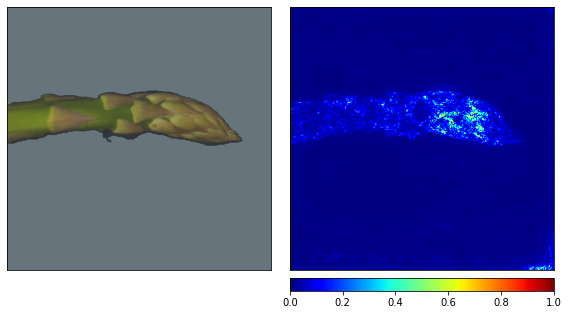

In [16]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_gradSHAP.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap='jet',
                                      show_colorbar=True)

# Captum Noise Tunnel with GradientsSHAP <br>

Default n_sample is 5 which generates 5 perturbed input tensors per image.
Computes integrated gradients for predicted value for each generated inpt and averages attributions accros all 5 perturbed inputs per image

In [31]:
from captum.attr import NoiseTunnel

noise_tunnel_shap = NoiseTunnel(gradient_shap)

attr_shap_nt = noise_tunnel_shap.attribute(input_img,
                                           n_samples=5,
                                           baselines=0*input_img,
                                           nt_type='smoothgrad')

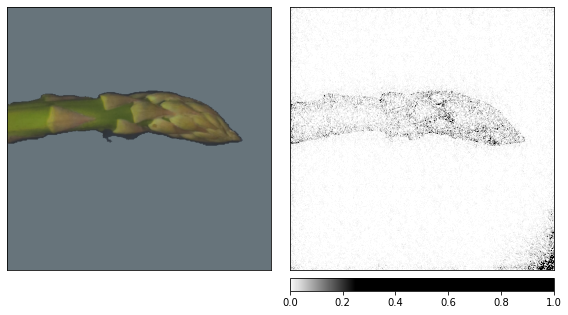

In [32]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_shap_nt.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "positive"],
                                      cmap=default_cmap,
                                      show_colorbar=True)

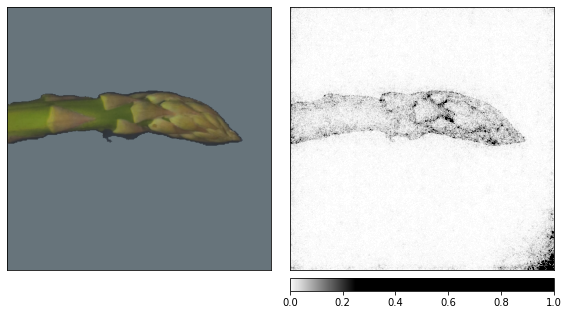

In [35]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_shap_nt.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap=default_cmap,
                                      show_colorbar=True)

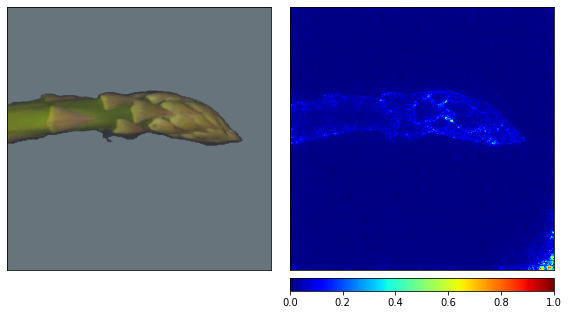

In [34]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_shap_nt.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap='jet',
                                      show_colorbar=True)

# Layer Conductance (Layer)
source code:https://captum.ai/api/layer.html

In [13]:
from captum.attr import LayerConductance

lc = LayerConductance(model, model.encoder.layer1)
attr_lc = lc.attribute(input_img)

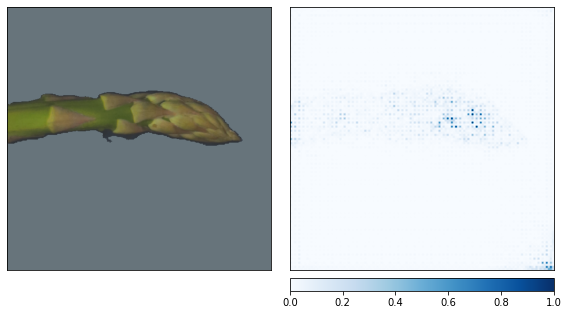

In [17]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_lc.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [30]:
lc = LayerConductance(model, model.encoder.layer2)
attr_lc = lc.attribute(input_img)

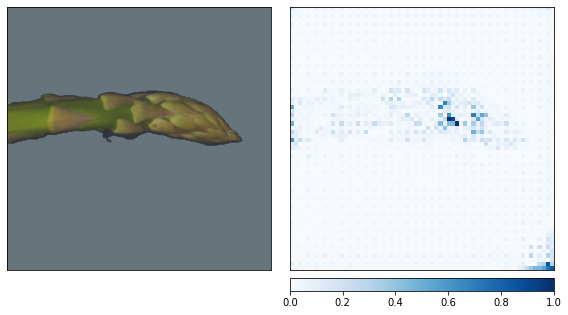

In [31]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_lc.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [32]:
lc = LayerConductance(model, model.encoder.layer3)
attr_lc = lc.attribute(input_img)

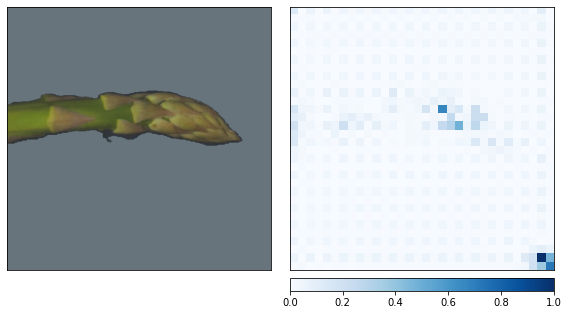

In [33]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_lc.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [35]:
lc = LayerConductance(model, model.encoder.layer4)
attr_lc = lc.attribute(input_img)

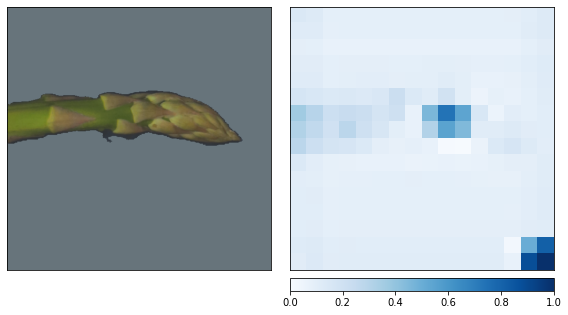

In [36]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_lc.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

## Defining baseline 

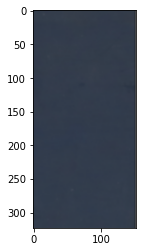

In [43]:
baseline_file = 'Baseline.PNG'

b_img = Image.open(baseline_file).convert('RGB')
plt.imshow(b_img)

In [44]:
transform = transforms.Compose([
                 transforms.Resize([512,512]),
                 transforms.ToTensor()
                ])

transformed_b_img = transform(b_img)

In [45]:
print(transformed_b_img.shape)
final_b_img = transformed_b_img.unsqueeze(0)
print(final_b_img.shape)

torch.Size([3, 512, 512])
torch.Size([1, 3, 512, 512])


Now, not just input_img, passed baseline tensor to attribute class function. <br>

In [46]:
lc = LayerConductance(model, model.encoder.layer1)
attr_lc = lc.attribute(input_img, final_b_img)

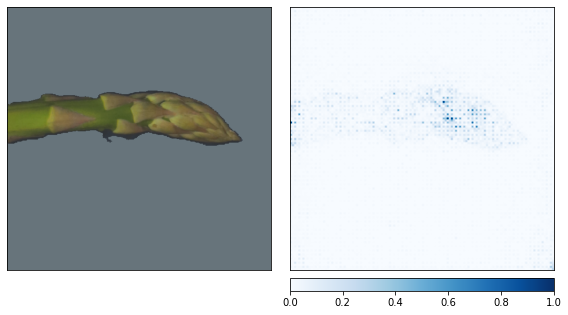

In [47]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_lc.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

And from the visulaized image, we can check there is no big difference between just passing input image and passing input image with baseline. If we pay attention, we can see the color intensity of a little dot is different from just layer conductance.

# Layer Gradient X Activation

In [18]:
from captum.attr import LayerGradientXActivation

layer_ga = LayerGradientXActivation(model, model.encoder.layer1)
attr_layer_gxa = layer_ga.attribute(input_img)

/home/SOKI/ImageFiles/asparagus_head_scoring/lib/python3.6/site-packages/captum/_utils/gradient.py:55: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  "required_grads has been set automatically." % index


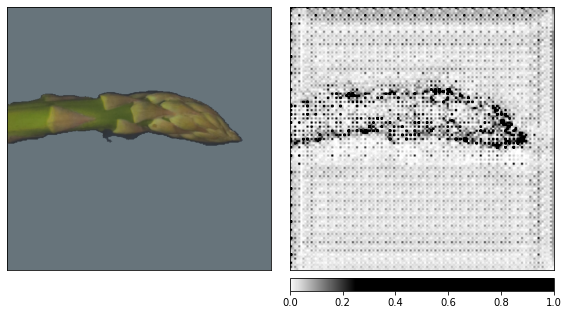

In [23]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap=default_cmap,
                                      show_colorbar=True,
                                      outlier_perc=2)

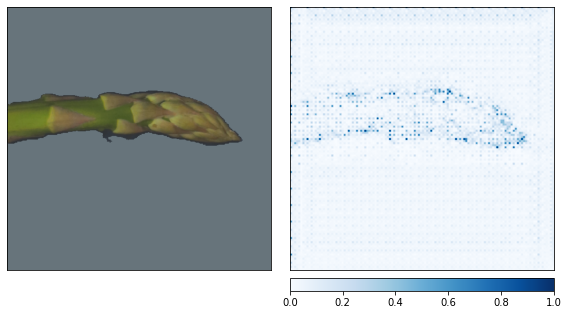

In [24]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [25]:
layer_ga = LayerGradientXActivation(model, model.encoder.layer2)
attr_layer_gxa = layer_ga.attribute(input_img)

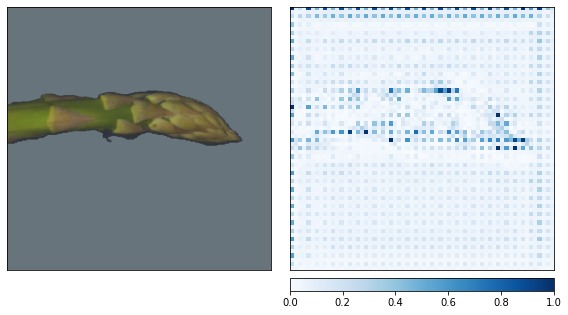

In [26]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [27]:
layer_ga = LayerGradientXActivation(model, model.encoder.layer3)
attr_layer_gxa = layer_ga.attribute(input_img)

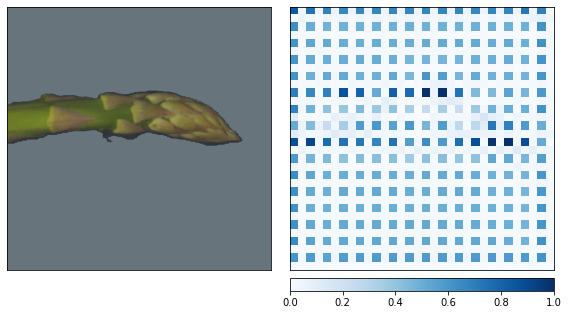

In [29]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      img1,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True)

# Captum Layer DeepLift (Layer)

In [48]:
from captum.attr import LayerDeepLift

l_deep_lift = LayerDeepLift(model, model.encoder.layer1)

attr_l_dl = l_deep_lift.attribute(input_img)

/home/SOKI/ImageFiles/asparagus_head_scoring/lib/python3.6/site-packages/captum/_utils/gradient.py:55: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  "required_grads has been set automatically." % index


RuntimeError: A Module ReLU(inplace=True) was detected that does not contain some of the input/output attributes that are required for DeepLift computations. This can occur, for example, if your module is being used more than once in the network.Please, ensure that module is being used only once in the network.

LayerDeepLift ERROR Forum Discussion: https://github.com/pytorch/captum/issues/378